In [1]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import gsw
import cmocean

In [2]:
root_dir = '/Users/zcasparcohen/codes/NIW/data/'
ds = xr.open_dataset(root_dir+'niskine_mooring_500m.nc')[['temp','salt']]
grid = xr.open_dataset(root_dir+'niskine_mooring_grid_500m.nc')

In [3]:
t0,t1 = '2001-01-06T16:00:00','2001-01-29T15:00:16'
t_storm = '2001-01-08'
time = pd.date_range(start=t0,periods=576,freq='1H')
ds=ds.assign_coords({'time':time})

In [4]:
ds['lat_rho'] = grid.lat_rho
ds['lon_rho'] = grid.lon_rho
ds['x_rho'] = grid.x_rho
ds['y_rho'] = grid.y_rho
ds['eta_rho'] = grid.eta_rho
ds['xi_rho'] = grid.xi_rho
#ds['lat'] = ds.lat_rho.mean('xi_rho').values
#ds['lon'] = ds.lon_rho.mean('eta_rho').values

In [5]:
ds = ds.rename({'eta_rho':'lat','xi_rho':'lon'})

In [6]:
ds['lon'] = ds.lon_rho.mean('lat').values
ds['lat'] = ds.lat_rho.mean('lon').values

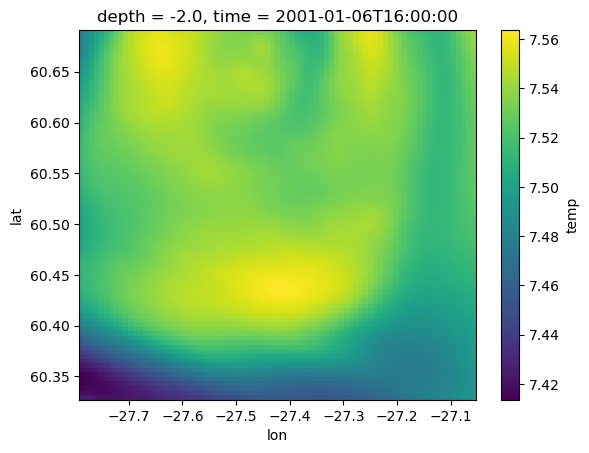

In [7]:
ds.temp.isel(time=0,depth=0).plot()

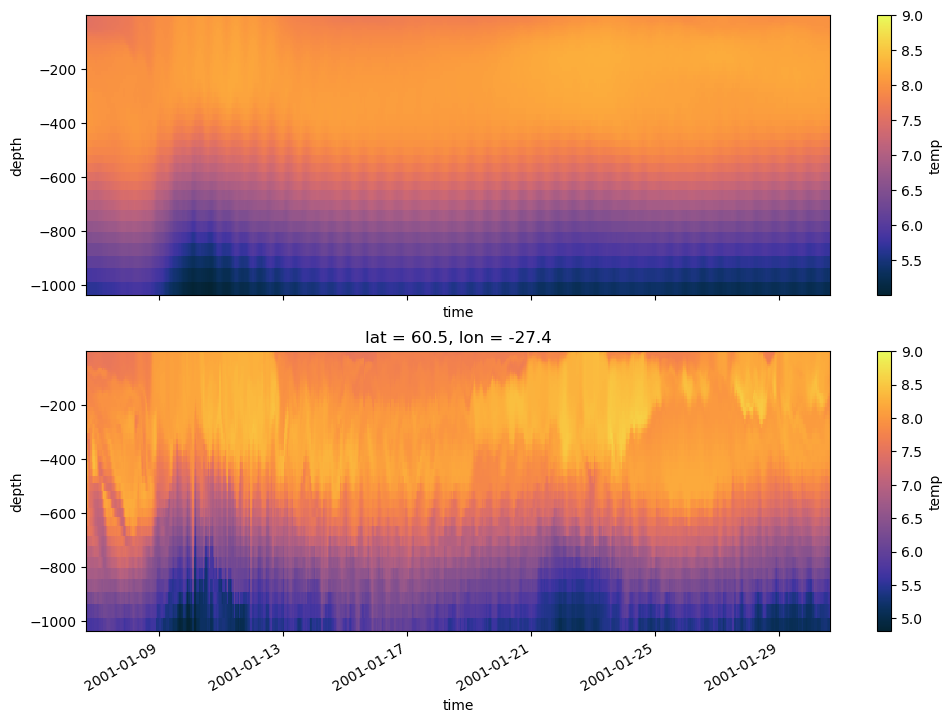

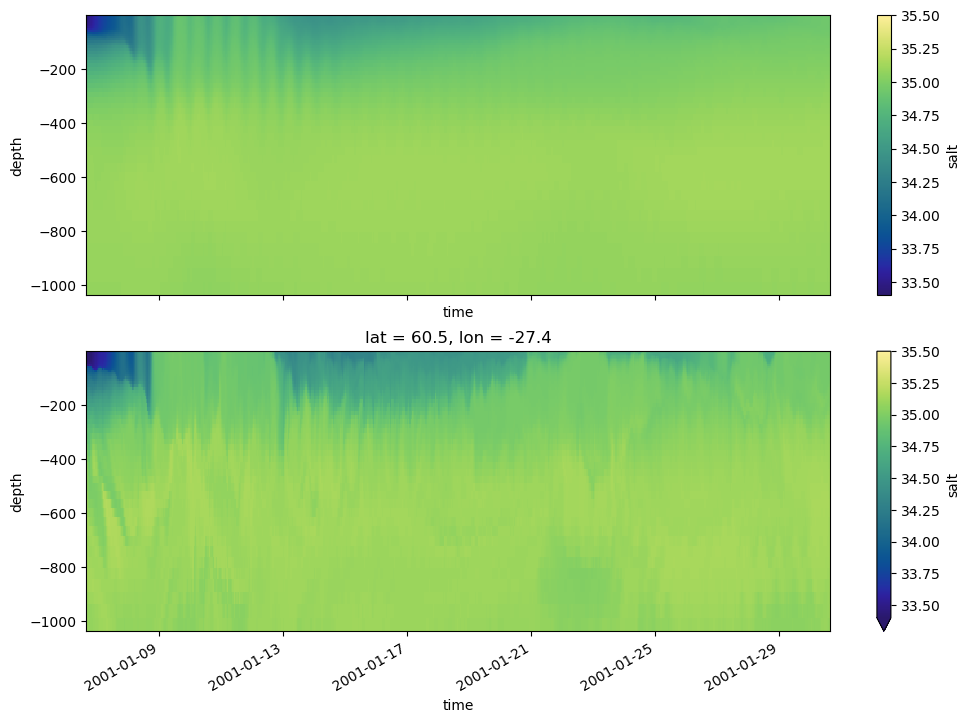

In [8]:
fig,ax=plt.subplots(2,1,figsize=(12,8),sharex=True)
ds.temp.mean(['lon','lat']).plot(ax=ax[0],y='depth',cmap=cmocean.cm.thermal,vmax=9)
ds.temp.sel(lon=-27.4,lat=60.5,method='nearest').plot(ax=ax[1],y='depth',cmap=cmocean.cm.thermal,vmax=9)

fig,ax=plt.subplots(2,1,figsize=(12,8),sharex=True)
ds.salt.mean(['lon','lat']).plot(ax=ax[0],y='depth',cmap=cmocean.cm.haline,vmax=35.5,vmin=33.4)
ds.salt.sel(lon=-27.4,lat=60.5,method='nearest').plot(ax=ax[1],y='depth',cmap=cmocean.cm.haline,vmax=35.5,vmin=33.4)

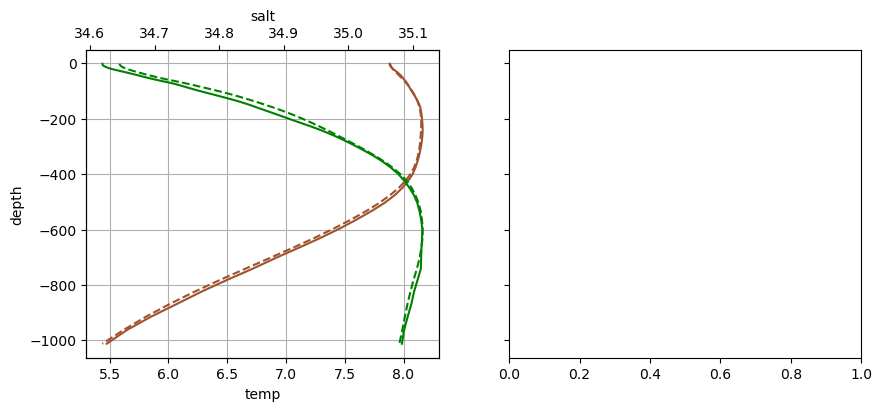

In [9]:
fig,ax=plt.subplots(1,1,figsize=(4,4),sharey=True)
ds.temp.sel(lon=-27.4,lat=60.5,method='nearest').mean('time').plot(ax=ax,y='depth',c='sienna')
ds.temp.mean(['lon','lat','time']).plot(ax=ax,y='depth',c='sienna',ls='--')
ax1=ax.twiny()
ds.salt.sel(lon=-27.4,lat=60.5,method='nearest').mean('time').plot(ax=ax1,y='depth',c='green')
ds.salt.mean(['lon','lat','time']).plot(ax=ax1,y='depth',c='g',ls='--')
ax1.grid()

In [10]:
p = gsw.p_from_z(ds.depth,ds.lat)

In [11]:
SA = gsw.SA_from_SP(ds.salt,p,ds.lon,ds.lat)
CT = gsw.CT_from_t(SA,ds.temp,p)


In [12]:
rho = gsw.density.rho(SA,CT,p)

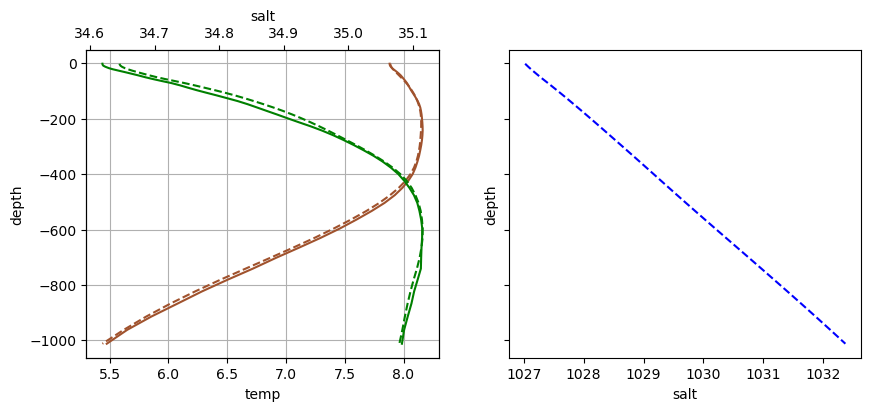

In [17]:
fig,ax=plt.subplots(1,2,figsize=(10,4),sharey=True)
ds.temp.sel(lon=-27.4,lat=60.5,method='nearest').mean('time').plot(ax=ax[0],y='depth',c='sienna')
ds.temp.mean(['lon','lat','time']).plot(ax=ax[0],y='depth',c='sienna',ls='--')
ax1=ax[0].twiny()
ds.salt.sel(lon=-27.4,lat=60.5,method='nearest').mean('time').plot(ax=ax1,y='depth',c='green')
ds.salt.mean(['lon','lat','time']).plot(ax=ax1,y='depth',c='g',ls='--')
ax[0].grid()

rho.mean(['lon','lat','time']).plot(ax=ax[1],y='depth',c='b',ls='--')

In [32]:
_ = [[[gsw.Nsquared(SA.sel(time=t,lon=lon,lat=lat,method='nearest').values,CT.sel(time=t,lon=lon,lat=lat,method='nearest').values,
                p.sel(lat=lat,method='nearest').values,lat=ds.lat.sel(lat=lat,method='nearest').values
                 )[0] for t in ds.time[:]] for lon in ds.lon[:]] for lat in ds.lat[:]]


In [95]:
(p.isel(lat=3)[0]+p.isel(lat=3)[1])/2

<xarray.DataArray 'depth' ()>
array(3.53344079)
Coordinates:
    lat      float64 60.34

In [99]:
pmid = ((p.shift({'depth':1})+p)/2).dropna('depth')

In [101]:
pmid

<xarray.DataArray 'depth' (depth: 53, lat: 81)>
array([[  3.53343701,   3.53343827,   3.53343953, ...,   3.53353507,
          3.53353633,   3.53353758],
       [  7.0669334 ,   7.06693593,   7.06693845, ...,   7.06712954,
          7.06713205,   7.06713455],
       [ 11.10528428,  11.10528825,  11.10529222, ...,  11.10559251,
         11.10559644,  11.10560038],
       ...,
       [900.95240598, 900.95272838, 900.95305076, ..., 900.97746221,
        900.97778223, 900.97810222],
       [949.11908317, 949.11942285, 949.1197625 , ..., 949.14548181,
        949.14581897, 949.14615611],
       [998.81839291, 998.81875041, 998.81910788, ..., 998.84617696,
        998.84653182, 998.84688665]])
Coordinates:
  * depth    (depth) float32 -5.0 -9.0 -13.0 -18.0 ... -914.0 -962.0 -1.012e+03
  * lat      (lat) float64 60.33 60.33 60.34 60.34 ... 60.68 60.68 60.68 60.69

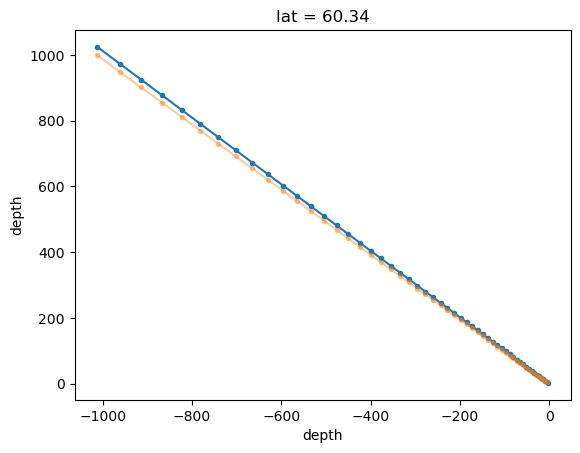

In [102]:
p.isel(lat=3).plot(marker='.')
pmid.isel(lat=3).plot(marker='.',alpha=0.4)

In [104]:
zmid = gsw.z_from_p(pmid,pmid.lat)

In [106]:
zmid

<xarray.DataArray 'depth' (depth: 53, lat: 81)>
array([[  -3.50000552,   -3.50000552,   -3.50000552, ...,   -3.50000552,
          -3.50000552,   -3.50000552],
       [  -7.0000098 ,   -7.0000098 ,   -7.0000098 , ...,   -7.0000098 ,
          -7.0000098 ,   -7.0000098 ],
       [ -11.0000098 ,  -11.0000098 ,  -11.0000098 , ...,  -11.0000098 ,
         -11.0000098 ,  -11.0000098 ],
       ...,
       [-890.50132805, -890.50132806, -890.50132806, ..., -890.50132809,
        -890.50132809, -890.50132809],
       [-938.00138374, -938.00138374, -938.00138374, ..., -938.00138378,
        -938.00138378, -938.00138378],
       [-987.00149985, -987.00149985, -987.00149985, ..., -987.00149989,
        -987.00149989, -987.00149989]])
Coordinates:
  * depth    (depth) float32 -5.0 -9.0 -13.0 -18.0 ... -914.0 -962.0 -1.012e+03
  * lat      (lat) float64 60.33 60.33 60.34 60.34 ... 60.68 60.68 60.68 60.69

In [107]:
N2 = xr.Dataset({'N2':(['lat','lon','time','depth'],np.array(_))},
                coords={'time':ds.time.values,'lon':ds.lon.values,'lat':ds.lat.values,'depth':zmid.mean('lat').values})


In [117]:
N2.to_netcdf(root_dir+'roms_stratification.nc')

In [118]:
xr.open_dataarray(root_dir+'roms_stratification.nc')

<xarray.DataArray 'N2' (lat: 81, lon: 81, time: 576, depth: 53)>
[200294208 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2001-01-06T16:00:00 ... 2001-01-30T15:00:00
  * lon      (lon) float64 -27.79 -27.78 -27.77 -27.76 ... -27.08 -27.07 -27.06
  * lat      (lat) float64 60.33 60.33 60.34 60.34 ... 60.68 60.68 60.68 60.69
  * depth    (depth) float64 -3.5 -7.0 -11.0 -15.5 ... -890.5 -938.0 -987.0

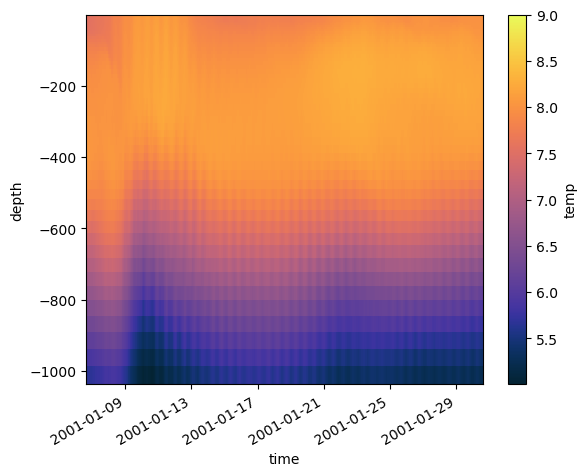

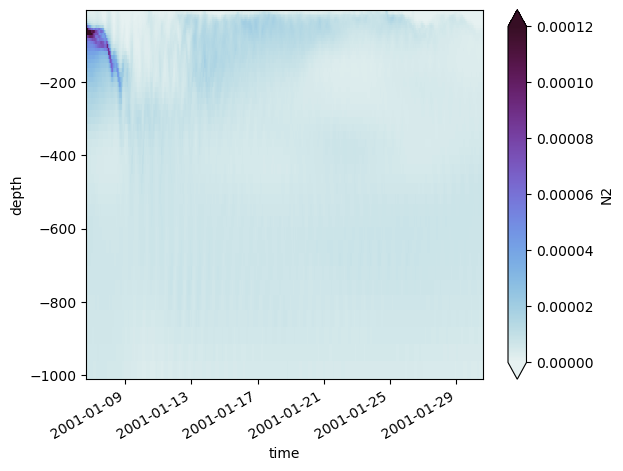

In [115]:
ds.temp.mean(['lon','lat']).plot(y='depth',cmap=cmocean.cm.thermal,vmax=9)
plt.figure()
N2.N2.mean(['lon','lat']).plot(y='depth',cmap=cmocean.cm.dense,vmax=1.2e-4,vmin=0)

In [ ]:
N2